# ECG Preprocessing
Downloads the MIT-BIH database, filters signals, extracts labelled beats, and saves them as a `.npz` file.

In [2]:
import os
import numpy as np
import wfdb
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import matplotlib.pyplot as plt

## Configuration

In [3]:
DATA_DIR    = 'data/mitdb'
OUTPUT_FILE = 'data/beats.npz'
FS          = 360   # sampling frequency (Hz)
WINDOW      = 250   # samples per beat
HALF        = WINDOW // 2

RECORD_IDS = [
    100, 101, 102, 103, 104, 105, 106, 107, 108, 109,
    111, 112, 113, 114, 115, 116, 117, 118, 119, 121,
    122, 123, 124, 200, 201, 202, 203, 205, 207, 208,
    209, 210, 212, 213, 214, 215, 217, 219, 220, 221,
    222, 223, 228, 230, 231, 232, 233, 234,
]

# Map individual AAMI symbols to 5 broad categories
BEAT_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
}

## Signal Filtering

In [4]:
def bandpass_filter(signal, lo=0.5, hi=40.0, order=4):
    nyq = FS / 2
    b, a = butter(order, [lo / nyq, hi / nyq], btype='band')
    return filtfilt(b, a, signal)

## Beat Extraction

In [5]:
def extract_beats(record_id):
    path = os.path.join(DATA_DIR, str(record_id))
    rec  = wfdb.rdrecord(path)
    ann  = wfdb.rdann(path, 'atr')

    signal = bandpass_filter(rec.p_signal[:, 0])
    signal = (signal - signal.mean()) / (signal.std() + 1e-8)

    beats, labels = [], []
    for idx, sym in zip(ann.sample, ann.symbol):
        category = BEAT_MAP.get(sym, 'Q')
        start, end = idx - HALF, idx + HALF
        if start < 0 or end > len(signal):
            continue
        beats.append(signal[start:end])
        labels.append(category)

    return beats, labels

## Download Database

In [8]:
os.makedirs(DATA_DIR, exist_ok=True)
print("Downloading ")
wfdb.dl_database("mitdb", dl_dir=DATA_DIR)
print("Download complete!")

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

## Process All Records

In [9]:
all_beats, all_labels = [], []

for rid in tqdm(RECORD_IDS, desc='Extracting beats'):
    try:
        b, l = extract_beats(rid)
        all_beats.extend(b)
        all_labels.extend(l)
    except Exception as exc:
        print(f'  Skipping record {rid}: {exc}')

print(f'\nTotal beats extracted: {len(all_beats)}')

Extracting beats: 100%|██████████| 48/48 [00:12<00:00,  3.82it/s]


Total beats extracted: 112561


## Encode Labels & Save

In [10]:
X = np.array(all_beats, dtype=np.float32)  # shape: (N, 250)

enc = LabelEncoder()
y   = enc.fit_transform(all_labels)          # integer labels for PyTorch CrossEntropyLoss

np.savez(OUTPUT_FILE, X=X, y=y, classes=enc.classes_)
print(f'Saved {len(X)} beats -> {OUTPUT_FILE}')
print(f'Classes : {enc.classes_}')
print(f'X shape : {X.shape} | y shape : {y.shape}')

Saved 112561 beats -> data/beats.npz
Classes : ['F' 'N' 'Q' 'S' 'V']
X shape : (112561, 250) | y shape : (112561,)


## Quick Visualisation : One Sample per Class

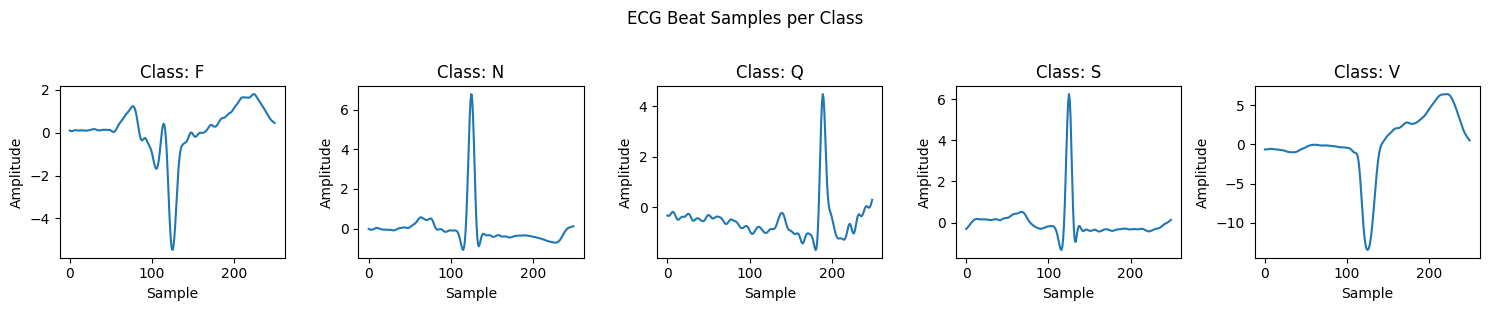


Class distribution: {np.str_('F'): 802, np.str_('N'): 90595, np.str_('Q'): 11148, np.str_('S'): 2781, np.str_('V'): 7235}


In [11]:
fig, axes = plt.subplots(1, len(enc.classes_), figsize=(15, 3))

for i, cls in enumerate(enc.classes_):
    sample_idx = np.where(y == i)[0][0]
    axes[i].plot(X[sample_idx])
    axes[i].set_title(f'Class: {cls}')
    axes[i].set_xlabel('Sample')
    axes[i].set_ylabel('Amplitude')

plt.suptitle('ECG Beat Samples per Class', y=1.02)
plt.tight_layout()
plt.savefig('data/sample_beats.png', dpi=100, bbox_inches='tight')
plt.show()

dist = {c: int((y == i).sum()) for i, c in enumerate(enc.classes_)}
print(f'\nClass distribution: {dist}')